# Lecture 26: Review for Exam 3
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/natrask/engr1050-fall2026/blob/main/NewMaterial/Lecture25_Nov23/lec25.ipynb)

# Zoom for today

Nat Trask is inviting you to a scheduled Zoom meeting.
Join Zoom Meeting
https://upenn.zoom.us/j/91497753589?pwd=HmasWB8Ly2WJgaUKM71LjloYU82Uf5.1

Meeting ID: 914 9775 3589
Passcode: 976097

## Overview

To help prepare for our final remaining Lecture, I'm putting together a summary here that will cover the material you should be comfortable with for the remaining exam. Because many folks are traveling, I have made this review virtual over zoom - the recording will be posted on the course Github to hopefully minimize disruption of whatever your Thanksgiving plans might be.

In [ ]:
# Import necessary libraries
import torch
import matplotlib.pyplot as plt
import numpy as np

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)

# Material on exam and closing reflections

The exam will feature the greatest hits of:
- Lecture 20: Vibe coding
- Lecture 21: Optimization and Newton's method
- Lecture 23: Automatic differentiation with PyTorch
- Lecture 24: Deep learning with MLPs
- Lecture 25: Binary classification

In the first unit of the course, we focused on Python fundamentals. In the second, we made sure we could apply those fundamentals to solve ODEs and run microcontrollers. In this unit, the focus was to build confidence using the Python basics to take a crack at PyTorch as a representative *big kid* Python library that you will have a high probability of needing to learn. 

We used Gemini as Colab's built in coding assistant to help us get past the steep learning curve. We practiced using Gemini to:
- Ask for explanations of how a given code works
- Use autocomplete to help find specific syntax or functions that we might need when learning a new library
We hopefully got some sense of the dangers of using a LLM:
- It is dangerous to ask it to write code. Getting help making plots and writing simple chunks of code is OK, but as you push into more ambitious tasks it can fail spectacularly
- It is not good for your continued growth as a programmer. It short circuits your critical thinking and spits out an answer that may or may not be correct, and many will fall into the trap of running AI-generated code **without critical thinking** or **validation that code produces correct responses**.

Nonetheless, it is here and we need to learn to use it, particularly since it will let us rapidly acquire new skills, like learning to make a given sensor go in our final project.

**Be careful!** There is a high probability that many of you are over-estimating your command on this unit's material if you used an LLM to make your way through the in-class exercises.

## Review Lecture 20: Vibe coding

**Exercise.** Give examples of a task where you feel a LLM can safely be used, and others where it cannot. Explain what steps you would take to establish a reasonable level of trust in AI-generated code, considering that in a professional setting you are legally responsible for code you generate, whether AI-generated or not.

## Review Lecture 22: Optimizaton and Newton's method

Recall that Newton's method is
$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$
and that we developed the following solver implementing it:
```python
class NewtonSolver:
    """
    Simple Newton solver returning roots of scalar equation f(x)=0. 
    Inputs:
    f : function
    df : function
    x0 : initial guess
    tol : tolerance for convergence (default 1e-8)
    maxiter : maximum number of iterations (default 50)
    """

    def __init__(self, f, df, x0, tol=1e-8, maxiter=50):
        self.f = f
        self.df = df
        self.x0 = float(x0)
        self.tol = tol
        self.maxiter = maxiter

    def solve(self):
        x = self.x0
        for n in range(self.maxiter):
            fx = float(self.f(x))
            if abs(fx) <= self.tol:
                return x, {"converged": True, "niter": n}
            dfx = float(self.df(x))
            if dfx == 0.0:
                return x, {"converged": False, "niter": n}
            x = x - fx / dfx
        return x, {"converged": False, "niter": self.maxiter}
```

**Exercise.** Choose an equation $f(x)$, and find a root $f(x_{root})=0$. Select the equation so that you can easily check whether your root is correct.

**Exercise.** Be comfortable with two configurations:
- I show you code using this class, and you explain what equation that code will solve.
- I give you an equation to solve, and you hand-write code using this class to solve it.

**Exercise.** Make sure you understand the derivation of Newton's method:
- Use Taylor's theorem to make a linear approximation around the most recent guess.
$$ f(x) = f(x_n) + f'(x_n) (x-x_n) $$
- To pick next guess, choose $x$ as the point where the linear approximation crosses the x-axis
$$f(x) = 0 \rightarrow 0 = f(x_n) + f'(x_n) (x_{n+1}-x_n) $$
- Simplify expression by solving for $x_{n+1}$
- Sketch method by hand using a graph of a simple function to build intuition for when the method will work (code below gives an example)
- List the cases where Newton can fail, and be prepared to explain whether you expect Newton to work for a given function and initial condition.

<>:72: SyntaxWarning: invalid escape sequence '\s'
<>:72: SyntaxWarning: invalid escape sequence '\s'
C:\Users\nattr\AppData\Local\Temp\ipykernel_31328\212922017.py:72: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(np.sqrt(3), 0, 'k*', markersize=15, label=f'True root: $x = \sqrt{{3}} \\approx {np.sqrt(3):.3f}$', zorder=6)


Newton's Method Iterations:
x_0 = 0.500000, f(x_0) = -1.375000
x_1 = -0.111111, f(x_1) = 0.331962
x_2 = 0.000926, f(x_2) = -0.002778
x_3 = -0.000000, f(x_3) = 0.000000


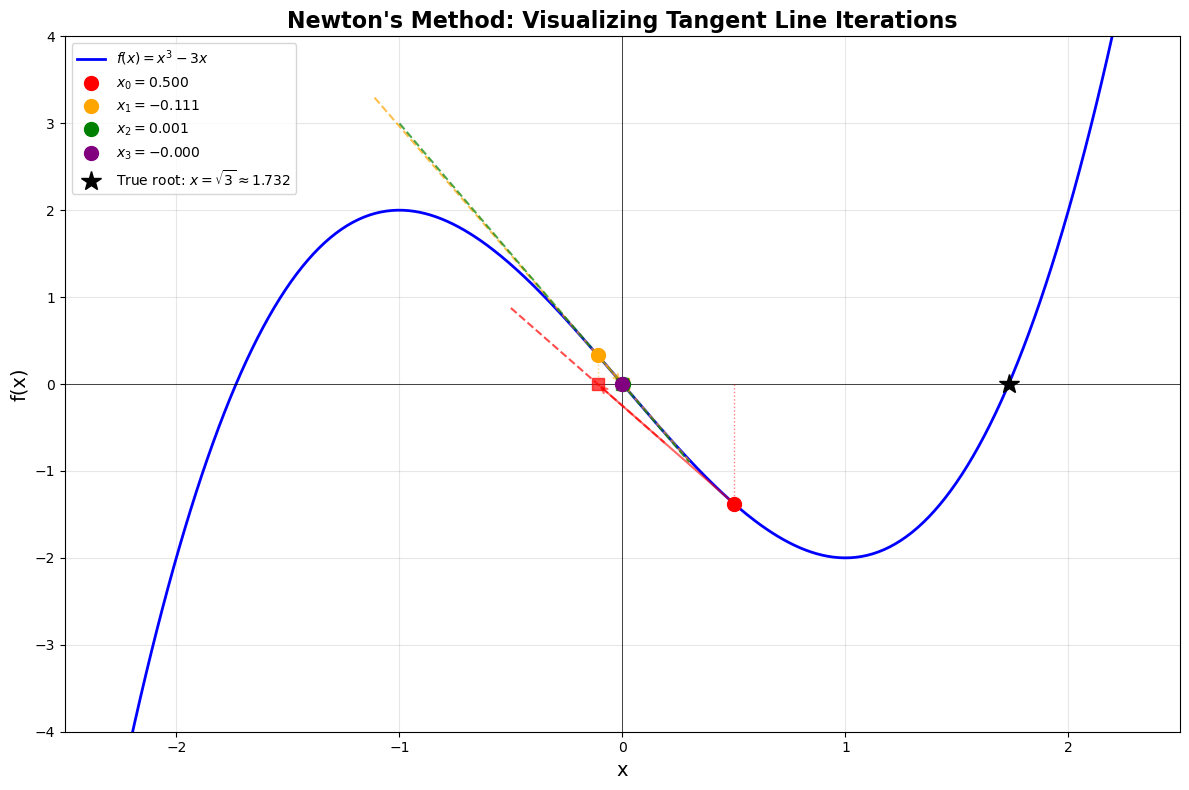

In [ ]:
# Visualize Newton's Method with tangent lines
import numpy as np
import matplotlib.pyplot as plt

# Define the function and its derivative
def f(x):
    return x**3 - 3*x

def df(x):
    return 3*x**2 - 3

# Initial guess
x0 = 0.5

# Perform Newton iterations
iterations = [x0]
for i in range(3):
    x_n = iterations[-1]
    x_next = x_n - f(x_n) / df(x_n)
    iterations.append(x_next)

print("Newton's Method Iterations:")
for i, x in enumerate(iterations):
    print(f"x_{i} = {x:.6f}, f(x_{i}) = {f(x):.6f}")

# Plot the function
x = np.linspace(-2.5, 2.5, 400)
y = f(x)

plt.figure(figsize=(12, 8))
plt.plot(x, y, 'b-', linewidth=2, label='$f(x) = x^3 - 3x$')
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)

# Plot each iteration with tangent line
colors = ['red', 'orange', 'green', 'purple']
for i in range(len(iterations) - 1):
    x_n = iterations[i]
    x_next = iterations[i+1]
    
    # Plot the point (x_n, f(x_n))
    plt.plot(x_n, f(x_n), 'o', color=colors[i], markersize=10, 
             label=f'$x_{i} = {x_n:.3f}$', zorder=5)
    
    # Draw tangent line: y - f(x_n) = f'(x_n)(x - x_n)
    # Tangent line: y = f(x_n) + f'(x_n)(x - x_n)
    slope = df(x_n)
    x_tangent = np.linspace(x_n - 1, x_next + 0.3, 100)
    y_tangent = f(x_n) + slope * (x_tangent - x_n)
    plt.plot(x_tangent, y_tangent, '--', color=colors[i], linewidth=1.5, alpha=0.7)
    
    # Draw vertical line from x-axis to the point
    plt.plot([x_n, x_n], [0, f(x_n)], ':', color=colors[i], linewidth=1, alpha=0.5)
    
    # Mark where tangent crosses x-axis (next iteration)
    plt.plot(x_next, 0, 's', color=colors[i], markersize=8, alpha=0.7, zorder=5)
    
    # Add arrow showing iteration
    if i < len(iterations) - 2:
        plt.annotate('', xy=(x_next, 0), xytext=(x_n, f(x_n)),
                    arrowprops=dict(arrowstyle='->', color=colors[i], 
                                  lw=1.5, alpha=0.6))

# Plot the final iteration point
x_final = iterations[-1]
plt.plot(x_final, f(x_final), 'o', color=colors[-1], markersize=10, 
         label=f'$x_{len(iterations)-1} = {x_final:.3f}$', zorder=5)
plt.plot([x_final, x_final], [0, f(x_final)], ':', color=colors[-1], linewidth=1, alpha=0.5)

# Mark the true root
plt.plot(np.sqrt(3), 0, 'k*', markersize=15, label=f'Root: $x = \sqrt{{3}} \\approx {np.sqrt(3):.3f}$', zorder=6)

plt.xlabel('x', fontsize=14)
plt.ylabel('f(x)', fontsize=14)
plt.title("Newton's Method: Visualizing Tangent Line Iterations", fontsize=16, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.xlim(-2.5, 2.5)
plt.ylim(-4, 4)
plt.tight_layout()
plt.show()

## Review Lecture 23: Automatic differentiation and gradient descent

Newton's method and gradient descent are given by the formulas
**Newton's Method** (for finding roots of $f(x) = 0$):

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

**Gradient Descent** (for minimizing a loss function $L(\theta)$):

$$\theta_{n+1} = \theta_n - \alpha \nabla L(\theta_n)$$

where $\alpha$ is the learning rate and $\nabla L(\theta_n)$ is the gradient of the loss with respect to parameters $\theta$.

**Exercise.** Explain how Newton's method can be used to minimize a function. 

**Exercise.** Explain the roll of $\alpha$ and $\frac{1}{f'}$ in both methods. Explain how to choose $\alpha$.

**Exercise.** What is a *local minimum* of a function compared to a *global minimum*? Which would you prefer to obtain? Which does Newton/gradient descent give you?

**Exercise.** For a simple function like $y = x^2$, draw what a single step of Newton would look like compared to a single step of gradient descent. Explain why each method would be preferable.

Starting point: x0 = 3.0
Gradient Descent (α=0.3): x1 = 1.2000
Newton's Method: x1 = 0.0000
True minimum: x = 0


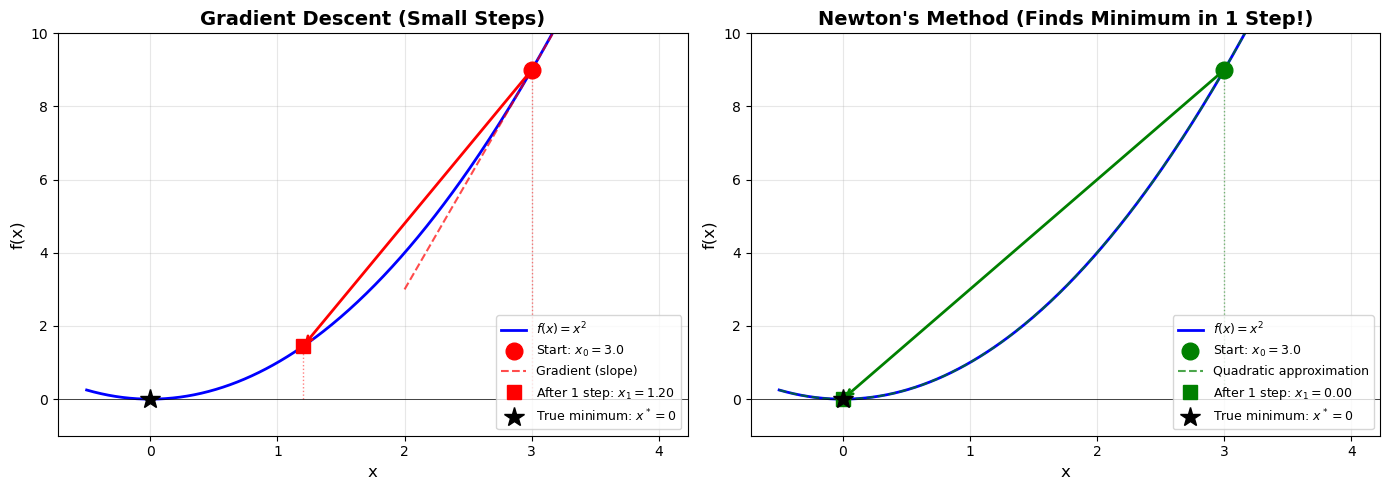

In [6]:
# Code to visually compare Newton's Method vs Gradient Descent for minimizing y = x^2
import numpy as np
import matplotlib.pyplot as plt

# Define function (we want to minimize this)
def f(x):
    return x**2

# First derivative (gradient)
def df(x):
    return 2*x

# Second derivative (for Newton's method)
def d2f(x):
    return 2.0

# Starting point
x0 = 3.0
learning_rate = 0.3  # For gradient descent

# Compute one step of each method
x_gd = x0 - learning_rate * df(x0)  # Gradient descent step
x_newton = x0 - df(x0) / d2f(x0)    # Newton's method step (for minimization: x - f'/f'')

print(f"Starting point: x0 = {x0}")
print(f"Gradient Descent (α={learning_rate}): x1 = {x_gd:.4f}")
print(f"Newton's Method: x1 = {x_newton:.4f}")
print(f"True minimum: x = 0")

# Plot
x = np.linspace(-0.5, 4, 400)
y = f(x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Gradient Descent
ax1.plot(x, y, 'b-', linewidth=2, label='$f(x) = x^2$')
ax1.plot(x0, f(x0), 'ro', markersize=12, label=f'Start: $x_0={x0}$', zorder=5)

# Draw gradient descent step
slope_gd = df(x0)
x_tangent = np.linspace(x0 - 1, x0 + 0.5, 100)
y_tangent = f(x0) + slope_gd * (x_tangent - x0)
ax1.plot(x_tangent, y_tangent, 'r--', linewidth=1.5, alpha=0.7, label='Gradient (slope)')

# Show the step
ax1.annotate('', xy=(x_gd, f(x_gd)), xytext=(x0, f(x0)),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax1.plot(x_gd, f(x_gd), 'rs', markersize=10, label=f'After 1 step: $x_1={x_gd:.2f}$', zorder=5)

# Draw vertical lines
ax1.plot([x0, x0], [0, f(x0)], 'r:', linewidth=1, alpha=0.5)
ax1.plot([x_gd, x_gd], [0, f(x_gd)], 'r:', linewidth=1, alpha=0.5)

ax1.plot(0, 0, 'k*', markersize=15, label='True minimum: $x^*=0$', zorder=6)
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x)', fontsize=12)
ax1.set_title('Gradient Descent (Small Steps)', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-1, 10)

# RIGHT: Newton's Method
ax2.plot(x, y, 'b-', linewidth=2, label='$f(x) = x^2$')
ax2.plot(x0, f(x0), 'go', markersize=12, label=f'Start: $x_0={x0}$', zorder=5)

# For Newton's method on optimization, we use the quadratic approximation
# f(x) ≈ f(x0) + f'(x0)(x-x0) + (1/2)f''(x0)(x-x0)^2
# This is a parabola that touches our function at x0
x_quad = np.linspace(-0.5, 4, 400)
y_quad = f(x0) + df(x0)*(x_quad - x0) + 0.5*d2f(x0)*(x_quad - x0)**2
ax2.plot(x_quad, y_quad, 'g--', linewidth=1.5, alpha=0.7, label='Quadratic approximation')

# Show Newton's step (goes directly to minimum of quadratic)
ax2.annotate('', xy=(x_newton, f(x_newton)), xytext=(x0, f(x0)),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax2.plot(x_newton, f(x_newton), 'gs', markersize=10, label=f'After 1 step: $x_1={x_newton:.2f}$', zorder=5)

# Draw vertical lines
ax2.plot([x0, x0], [0, f(x0)], 'g:', linewidth=1, alpha=0.5)
ax2.plot([x_newton, x_newton], [0, f(x_newton)], 'g:', linewidth=1, alpha=0.5)

ax2.plot(0, 0, 'k*', markersize=15, label='True minimum: $x^*=0$', zorder=6)
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('f(x)', fontsize=12)
ax2.set_title("Newton's Method (Finds Minimum in 1 Step!)", fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-1, 10)

plt.tight_layout()
plt.show()

PyTorch is a tool to automatically take derivatives, which allows us to do gradient descent on very complicated looking functions.

**Exercise.** Be able to sketch a computational graph associated with a given function, and describe in simple terms (eg. qualitatively, not necessarily with formulas) how PyTorch processes that graph into a gradient.

**Exercise.** Be able to use PyTorch for automatic differentiation in two modes:
1. If someone gives you PyTorch code taking a backward pass, be able to note the output
2. If I give you a complicated expression (e.g. $y(x) = \exp 17 (x+4)^2)$ ) use `.backward` to take a derivative of it 
```python
x = torch.tensor(3.0, requires_grad=True)
y = x**2
y.backward()  # This computes the derivative
print("dy/dx at x=3:", x.grad)
```

**Exercise.** Revist the exercise where we fit a stress-strain law to experimental data. If somebody gives you experimental data, understanding how each part of the following "recipe" for model-fitting works.
1. Specifying a model using `modelClass`
2. Specifying a loss function
3. Applying gradient descent to fit the model

## Review Lecture 24: Deep learning with MLPs

In Lecture 24 we introduced the **multilayer perceptron** or **MLP**. The equation for an MLP consisting of $N$ layers is given by

$$
\begin{align*}
\mathbf{h}_1 &= \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) \\
\mathbf{h}_2 &= \sigma(\mathbf{W}_2 \mathbf{h}_1 + \mathbf{b}_2) \\
&\vdots \\
\mathbf{h}_N &= \sigma(\mathbf{W}_N \mathbf{h}_{N-1} + \mathbf{b}_N) \\
\mathbf{y} &= \mathbf{W}_{out} \mathbf{h}_N
\end{align*}
$$

We showed how `modelClass` can be altered to implement an MLP.

```python
class MLP_modelClass:
    def __init__(self, input_dim, hidden_dim, output_dim):
        # Initialize a 2-layer MLP
        # input_dim - dimension of input (e.g., 1 for scalar input)
        # hidden_dim - number of neurons in hidden layer
        # output_dim - dimension of output (e.g., 1 for scalar output)
        
        # Layer 1: input -> hidden
        self.W1 = torch.randn(hidden_dim, input_dim, requires_grad=True)
        self.b1 = torch.randn(hidden_dim, requires_grad=True)
        
        # Layer 2: hidden -> output
        self.W2 = torch.randn(output_dim, hidden_dim, requires_grad=True)
        self.b2 = torch.randn(output_dim, requires_grad=True)
    
    def forward(self, x):
        # Layer 1: compute h1 = tanh(W1*x + b1)
        z1 = self.W1 @ x + self.b1   # Linear transformation
        h1 = torch.tanh(z1)          # Activation function
        
        # Layer 2: compute y = W2*h1 + b2
        y = self.W2 @ h1 + self.b2   # Linear transformation (no activation on output)
        
        return y
```

**Exercise.** Understand the shapes of the weights and biases. If you are given an initializer, can you state what size `self.W2` is? `self.b1`? What are the requirements on the shapes of each for the class to make sense? What does the neural network output?

**Exercise.** Write code to alter the class so that it has an additional hidden layer.

**Exercise.** Modify the activation function so that it uses `torch.ReLU`.

We used the following code to train our MLP.

```python
# Initialize MLP model
model = MLP_modelClass(input_dim=1, hidden_dim=40, output_dim=1)

# Training parameters
learning_rate = 0.001
num_steps = 20000
batch_size = 10

for step in range(num_steps):
    # Zero gradients at the start of each step
    if model.W1.grad is not None:
        model.W1.grad.zero_()
        model.b1.grad.zero_()
        model.W2.grad.zero_()
        model.b2.grad.zero_()
    
    # Accumulate loss as a tensor
    total_loss = torch.tensor(0.0, requires_grad=True)
    
    # Randomly select batch_size data points
    for j in range(batch_size):
        i = torch.randint(0, len(x_data), (1,)).item()
        
        x = torch.tensor([x_data[i].item()], dtype=torch.float32)
        y_true = torch.tensor([y_data[i].item()], dtype=torch.float32)
        
        # Forward pass
        y_pred = model.forward(x)
        
        # Compute loss and add to total (keep as tensor)
        loss = (y_pred - y_true)**2
        total_loss = total_loss + loss.sum()
    
    # Backward pass on the accumulated loss
    total_loss.backward()
    
    # Update parameters
    with torch.no_grad():
        model.W1 -= learning_rate * model.W1.grad
        model.b1 -= learning_rate * model.b1.grad
        model.W2 -= learning_rate * model.W2.grad
        model.b2 -= learning_rate * model.b2.grad
    
    # Print progress every 100 steps
    if step % 100 == 0:
        print(f"Step {step}, Avg Loss: {total_loss.item()/batch_size:.4f}")

        #loss on entire dataset
        total_loss = torch.tensor(0.0, requires_grad=False)
        for i in range(len(x_data)):
            x = torch.tensor([x_data[i].item()], dtype=torch.float32)
            y_true = torch.tensor([y_data[i].item()], dtype=torch.float32)
            
            # Forward pass
            y_pred = model.forward(x)
            
            # Compute loss and add to total
            loss = (y_pred - y_true)**2
            total_loss = total_loss + loss.sum()
        print(f"Final Avg Loss on entire dataset: {total_loss.item()/len(x_data):.4f}")
```

**Exercise.** This code uses *stochastic gradient descent*. Explain in words what SGD does. Highlight where in the training loop we have implemented SGD. Explain why we use SGD and its impact on the speed and accuracy when training an MLP.

**Exercise.** What is `batch_size`? What does `model.forward` do? What does `total_loss.backward` do? Why do we call `_zero()`?

**Exercise.** Write down a mathematical formula for the loss that this loop minimizes.

**Exercise.** We worked through an example of a regression problem where we predicted the impact of various manufacturing parameters on the yield strength of concrete. Come up with a list of a few engineering regression problems where you have to map from some inputs to predict a scalar quantity.

## Review Lecture 25: Binary classification

In Lecture 25, we showed how to use an MLP to perform *binary classification*. **While regression maps inputs to a numerical output, binary classification maps inputs to a True/False probability**. In class we introduced the following architecture:

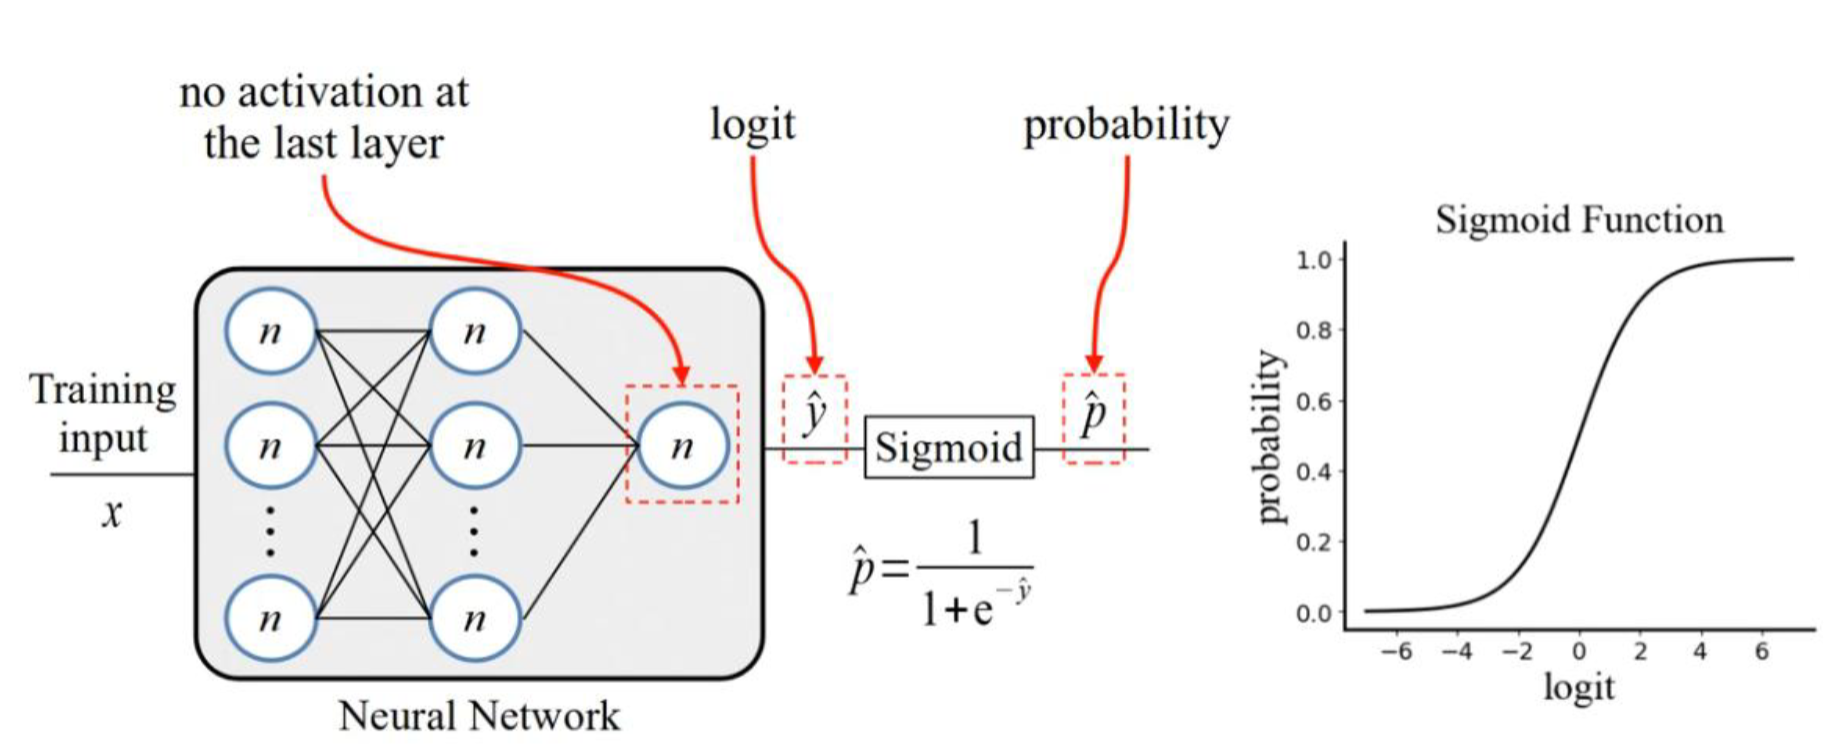

**Exercise.** To output a random variable, this architecture must output a probability between 0 and 1 of an event being true. Explain what is different from the MLP architecture so that this outputs a probability instead of a real number?

**Exercise.** Make a one-line modification to the MLP class, using `torch.sigmoid`, to build the binary classification model.

For this model we work with a **binary cross-entropy loss**:
$$\text{BCE}(y, \hat{y}) = -\left[y \log(\hat{y}) + (1-y) \log(1-\hat{y})\right]$$

where:
- $y \in \{0, 1\}$ is the true label
- $\hat{y} \in (0, 1)$ is the predicted probability




**Exercise.** Sketch by hand what this function looks like, in the two cases where $y=0$ and $y=1$. Explain why driving the cross-entropy loss to zero will give a model which gives correct classifications.

**Exercise.** If someone gives you a model and a training loop, be able to identify if the problem is set up to perform regression or for classification.

**Exercise.** Provide an example of a sensor reading that could be provided as an input to a binary classification prediction, similar to the bearing example we discussed in lecture.